In [1]:
from trading.backtest.strategy import process_symbol
from trading.utils.plots import plot_trades_scatter
import pandas as pd

## Backtest

In [2]:
date = "2025-02-02"
fmt   = "%Y-%m-%d"

vBOT = "0.0.1"

INITIAL_CAPITAL = 100_000  
capital = INITIAL_CAPITAL 
amount_per_trade = 1_000

ticks = ["BTCUSDT", "XRPUSDT", "ETHUSDT"]

In [3]:
# Backtesting
df_dict = {}

results = [process_symbol(symbol, date, fmt, "15m", 1, 8, ret_data=True) for symbol in ticks]
ops = []
for result, df_after in results:
    if result is not None:
        ops.append(result)
        df_dict[result["symbol"]] = df_after
    
df = pd.DataFrame(ops)

if df.empty:
    print(f"No operations launched at {date}\n")
    raise Exception("Empty DataFrame.")
else:
    print(f"{len(df)} operations launched at {date}\n")
    
df["version"] = vBOT
df["started_at"] = date
df['capital'] = 0.0
df['leverage'] = 1
df['result'] = df['real_pnl'].apply(lambda x: 'WON' if x > 0 else ('LOST' if x < 0 else None))
    
daily_pnl = df["real_pnl"].sum()

for idx, row in df.iterrows():
    capital += row['real_pnl']
    df.loc[idx, "capital"] = capital
print(f"Capital actualizado tras {date}: {capital:.2f}")

print("Completed!\n")


3 operations launched at 2025-02-02

Capital actualizado tras 2025-02-02: 100007.75
Completed!



## Results

In [4]:
display(df)

,symbol,side,qty,amount,stoploss,takeprofit,entry_time,exit_time,duration,entry_price,exit_price,pnl,real_pnl,closed_by,version,started_at,capital,leverage,result
0,BTCUSDT,BUY,0.011070,1000.0,89434.125000,91240.875000,2025-02-02 03:53:00,2025-02-02 04:01:00,8,90337.50000,89434.125000,-10.0,-10.748,stoploss,0.0.1,2025-02-02,99989.252,1,LOST
1,XRPUSDT,SELL,340.006528,1000.0,2.970531,2.911709,2025-02-02 00:00:00,2025-02-02 00:01:00,1,2.94112,2.911709,10.0,9.252,takeprofit,0.0.1,2025-02-02,99998.504,1,WON
2,ETHUSDT,BUY,0.329506,1000.0,3004.496550,3065.193450,2025-02-02 02:20:00,2025-02-02 02:21:00,1,3034.84500,3065.193450,10.0,9.248,takeprofit,0.0.1,2025-02-02,100007.752,1,WON


In [5]:
print("Max amount", "\n", "-"*30)
print(df['amount'].max())
print("\nClosed by counts", "\n", "-"*30)
print(df["closed_by"].value_counts())
print("\nResult counts", "\n", "-"*30)
print(df["result"].value_counts())

Max amount 
 ------------------------------
1000.0

Closed by counts 
 ------------------------------
closed_by
takeprofit    2
stoploss      1
Name: count, dtype: int64

Result counts 
 ------------------------------
result
WON     2
LOST    1
Name: count, dtype: int64


#### Visualizar resultados

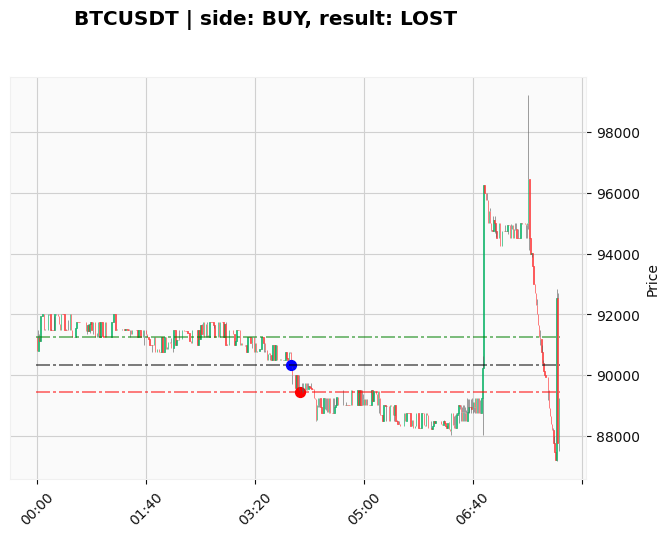

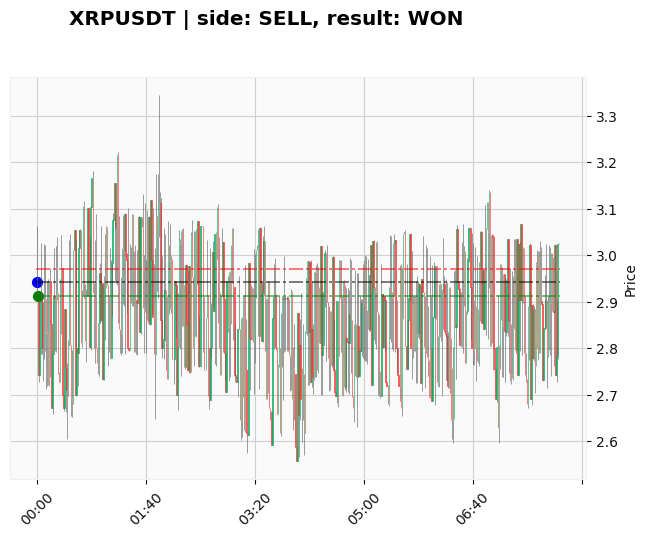

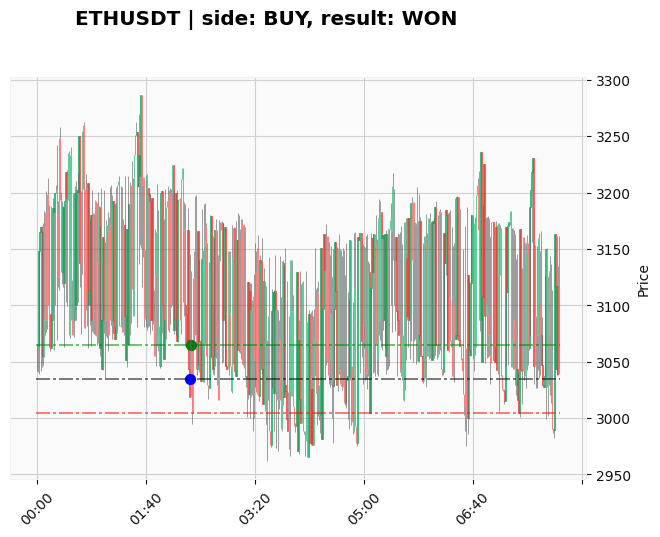

In [6]:
plot_trades_scatter(df, df_dict)